# 02 - Modélisation & Évaluation
**Tâche** : Régression — Prédiction des ventes (`Sales`) à partir des budgets marketing.


## 1. Imports

In [5]:
%pip uninstall -y shap numba llvmlite
%pip uninstall -y numpy shap numba llvmlite
%pip install --no-cache-dir --force-reinstall "numpy<2" "numba==0.60.0" "llvmlite==0.43.0" "shap==0.46.0" --trusted-host pypi.org --trusted-host files.pythonhosted.org --trusted-host pypi.python.org

Found existing installation: shap 0.46.0
Uninstalling shap-0.46.0:
  Successfully uninstalled shap-0.46.0
Found existing installation: numba 0.60.0
Uninstalling numba-0.60.0:
  Successfully uninstalled numba-0.60.0
Found existing installation: llvmlite 0.43.0
Uninstalling llvmlite-0.43.0:
  Successfully uninstalled llvmlite-0.43.0
Note: you may need to restart the kernel to use updated packages.
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 73.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 103.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 93.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 95.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 83.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modèles ML
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Modèle Deep Learning
from sklearn.neural_network import MLPRegressor

# Interprétabilité
from sklearn.inspection import permutation_importance
import shap

import joblib
import os

print('✅ Imports OK')

✅ Imports OK


## 2. Chargement des données

In [3]:
df = pd.read_csv('../data/processed/marketing_and_sales_clean.csv')

print(f'Shape : {df.shape}')
print(f'\nValeurs manquantes :\n{df.isnull().sum()}')
display(df.head())

Shape : (4546, 5)

Valeurs manquantes :
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64


,TV,Radio,Social Media,Influencer,Sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


## 3. Préparation des données

In [4]:
# ── 3.1 Encodage ordinal de Influencer ──────────────────────
INFLUENCER_ORDER = ['Nano', 'Micro', 'Macro', 'Mega']

df['Influencer_encoded'] = OrdinalEncoder(
    categories=[INFLUENCER_ORDER]
).fit_transform(df[['Influencer']]).astype(int)

print('Mapping Influencer :')
print({v: i for i, v in enumerate(INFLUENCER_ORDER)})
display(df[['Influencer', 'Influencer_encoded']].value_counts().reset_index())

Mapping Influencer :
{'Nano': 0, 'Micro': 1, 'Macro': 2, 'Mega': 3}


,Influencer,Influencer_encoded,count
0,Mega,3,1152
1,Micro,1,1148
2,Nano,0,1134
3,Macro,2,1112


In [5]:
# ── 3.2 Définition features / cible ─────────────────────────
FEATURES = ['TV', 'Radio', 'Social Media', 'Influencer_encoded']
TARGET   = 'Sales'

X = df[FEATURES]
y = df[TARGET]

print(f'Features : {FEATURES}')
print(f'Cible    : {TARGET}')
print(f'Shape X  : {X.shape} | Shape y : {y.shape}')

Features : ['TV', 'Radio', 'Social Media', 'Influencer_encoded']
Cible    : Sales
Shape X  : (4546, 4) | Shape y : (4546,)


In [6]:
# ── 3.3 Train / Test split 80/20 ────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes')

Train : 3636 lignes | Test : 910 lignes


In [7]:
# ── 3.4 Pipeline de preprocessing (évite le data leakage) ───
numeric_features     = ['TV', 'Radio', 'Social Media']
passthrough_features = ['Influencer_encoded']

preprocessor = ColumnTransformer(transformers=[
    ('scaler', StandardScaler(), numeric_features),
    ('pass',   'passthrough',   passthrough_features),
])

# Fit UNIQUEMENT sur le train → appliqué sur train ET test
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print('✅ Preprocessing OK — data leakage évité')
print(f'X_train_proc shape : {X_train_proc.shape}')

✅ Preprocessing OK — data leakage évité
X_train_proc shape : (3636, 4)


## 4. Modélisation — 4 modèles comparés

In [8]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Entraîne un modèle et retourne ses métriques."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)

    # Cross-validation R² (5 folds)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')

    print(f'\n── {name} ──')
    print(f'  MAE  : {mae:,.2f}')
    print(f'  RMSE : {rmse:,.2f}')
    print(f'  R²   : {r2:.4f}')
    print(f'  CV R² (mean ± std) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    return {
        'Modèle': name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R²': round(r2, 4),
        'CV R² mean': round(cv_scores.mean(), 4),
        'CV R² std': round(cv_scores.std(), 4),
        'model_obj': model,
        'y_pred': y_pred,
    }

results = []

In [9]:
# ── Modèle 1 : Régression Linéaire (baseline) ───────────────
lr = LinearRegression()
results.append(evaluate_model('Régression Linéaire', lr, X_train_proc, y_train, X_test_proc, y_test))


── Régression Linéaire ──
  MAE  : 2,312.78
  RMSE : 2,884.92
  R²   : 0.9990
  CV R² (mean ± std) : 0.9990 ± 0.0000


In [10]:
# ── Modèle 2 : Random Forest ─────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42)
results.append(evaluate_model('Random Forest', rf, X_train_proc, y_train, X_test_proc, y_test))


── Random Forest ──
  MAE  : 2,729.71
  RMSE : 3,357.43
  R²   : 0.9987
  CV R² (mean ± std) : 0.9987 ± 0.0000


In [11]:
# ── Modèle 3 : Gradient Boosting ─────────────────────────────
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
results.append(evaluate_model('Gradient Boosting', gb, X_train_proc, y_train, X_test_proc, y_test))


── Gradient Boosting ──
  MAE  : 2,355.06
  RMSE : 2,951.50
  R²   : 0.9990
  CV R² (mean ± std) : 0.9989 ± 0.0000


In [12]:
# ── Modèle 4 : MLP (Deep Learning) ───────────────────────────
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
results.append(evaluate_model('MLP (Deep Learning)', mlp, X_train_proc, y_train, X_test_proc, y_test))


── MLP (Deep Learning) ──
  MAE  : 4,661.89
  RMSE : 6,282.40
  R²   : 0.9953
  CV R² (mean ± std) : 0.9281 ± 0.0034


## 5. Tableau comparatif des modèles

In [16]:
df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['model_obj', 'y_pred']}
    for r in results
])

df_results = df_results.sort_values('R²', ascending=False).reset_index(drop=True)
display(df_results.style.highlight_max(subset=['R²', 'CV R² mean'], color='blue')
                        .highlight_min(subset=['MAE', 'RMSE', 'CV R² std'], color='blue'))

,Modèle,MAE,RMSE,R²,CV R² mean,CV R² std
0,Régression Linéaire,2312.780000,2884.920000,0.999000,0.999000,0.000000
1,Gradient Boosting,2355.060000,2951.500000,0.999000,0.998900,0.000000
2,Random Forest,2729.710000,3357.430000,0.998700,0.998700,0.000000
3,MLP (Deep Learning),4661.890000,6282.400000,0.995300,0.928100,0.003400


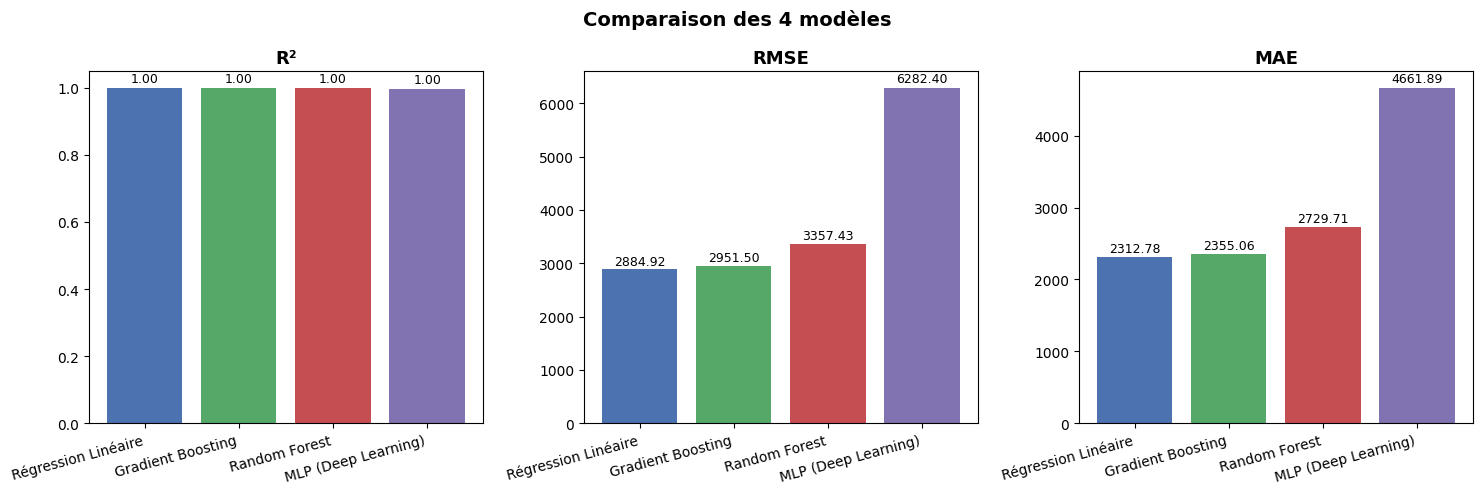

In [17]:
# ── Graphique comparatif ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE']):
    bars = ax.bar(df_results['Modèle'], df_results[metric], color=colors)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticklabels(df_results['Modèle'], rotation=15, ha='right')
    for bar, val in zip(bars, df_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*bar.get_height(),
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparaison des 4 modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Analyse des résidus (modèle final)

✅ Meilleur modèle : Régression Linéaire (R² = 0.999)


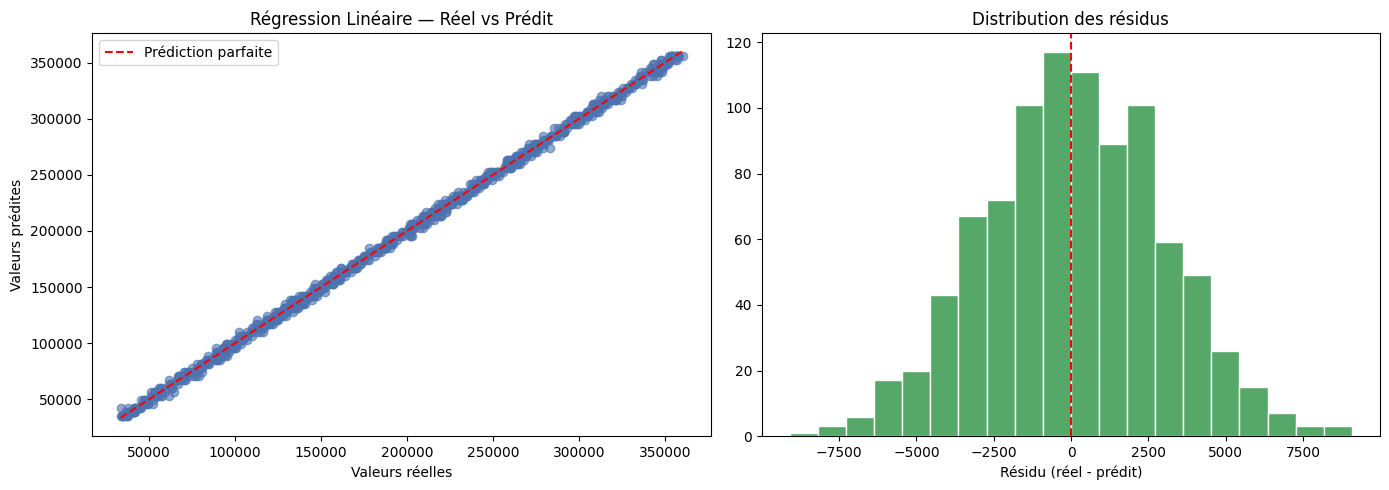

In [18]:
# On prend le modèle avec le meilleur R²
best = max(results, key=lambda r: r['R²'])
best_name  = best['Modèle']
best_model = best['model_obj']
y_pred_best = best['y_pred']
residuals   = y_test.values - y_pred_best

print(f'✅ Meilleur modèle : {best_name} (R² = {best["R²"]})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Valeurs réelles vs prédites
axes[0].scatter(y_test, y_pred_best, alpha=0.6, color='#4C72B0')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles')
axes[0].set_ylabel('Valeurs prédites')
axes[0].set_title(f'{best_name} — Réel vs Prédit')
axes[0].legend()

# Distribution des résidus
axes[1].hist(residuals, bins=20, color='#55A868', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Résidu (réel - prédit)')
axes[1].set_title('Distribution des résidus')

plt.tight_layout()
plt.show()

## 7. Interprétabilité — Feature Importance

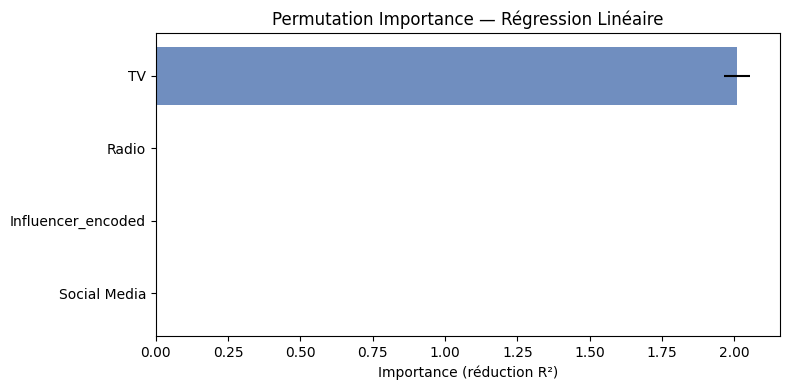

,Feature,Importance (mean),Std
0,TV,2.010843e+00,4.460686e-02
1,Radio,4.128012e-07,4.464919e-07
3,Influencer_encoded,-2.215558e-07,6.873255e-07
2,Social Media,-6.044683e-07,6.575011e-07


In [19]:
feature_names = numeric_features + passthrough_features

# Permutation Importance (agnostique au modèle)
perm_imp = permutation_importance(
    best_model, X_test_proc, y_test, n_repeats=10, random_state=42
)

df_perm = pd.DataFrame({
    'Feature': feature_names,
    'Importance (mean)': perm_imp.importances_mean,
    'Std': perm_imp.importances_std,
}).sort_values('Importance (mean)', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(df_perm['Feature'], df_perm['Importance (mean)'],
         xerr=df_perm['Std'], color='#4C72B0', alpha=0.8)
plt.xlabel('Importance (réduction R²)')
plt.title(f'Permutation Importance — {best_name}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

display(df_perm)

In [20]:
# ── Feature importance native (si Random Forest ou Gradient Boosting) ──
if hasattr(best_model, 'feature_importances_'):
    df_fi = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(8, 4))
    plt.barh(df_fi['Feature'], df_fi['Importance'], color='#C44E52', alpha=0.8)
    plt.xlabel('Importance (Gini / réduction variance)')
    plt.title(f'Feature Importance native — {best_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f'Pas de feature_importances_ natif pour {best_name}')

Pas de feature_importances_ natif pour Régression Linéaire


## 8. SHAP — Explicabilité avancée

  0%|          | 0/50 [00:00<?, ?it/s]

AssertionError: Feature and SHAP matrices must have the same number of rows!

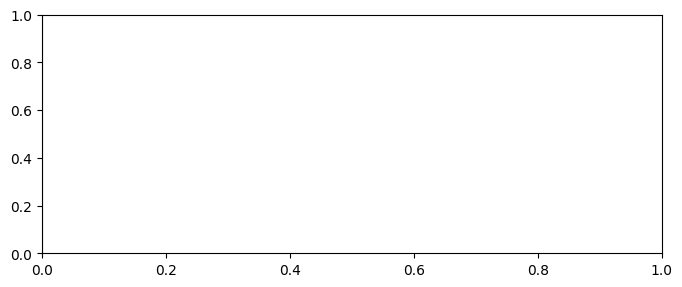

In [22]:
# SHAP fonctionne bien avec tree-based models (RF, GB)
# Pour MLP on utilise un KernelExplainer (plus lent)
import shap

X_test_df = pd.DataFrame(X_test_proc, columns=feature_names)

if best_name in ['Random Forest', 'Gradient Boosting']:
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_df)
else:
    explainer   = shap.KernelExplainer(best_model.predict, shap.sample(X_test_df, 50))
    shap_values = explainer.shap_values(X_test_df.iloc[:50])

# Summary plot global
plt.figure()
shap.summary_plot(shap_values, X_test_df, feature_names=feature_names, show=True)
plt.title(f'SHAP Summary — {best_name}')
plt.tight_layout()

In [ ]:
# Explication locale : 1ère observation du test set
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_df.iloc[0],
    feature_names=feature_names
)

## 9. Sauvegarde du meilleur modèle

In [23]:
os.makedirs('../model', exist_ok=True)

joblib.dump(best_model,   '../model/best_model.pkl')
joblib.dump(preprocessor, '../model/preprocessor.pkl')

print(f'✅ Modèle sauvegardé : {best_name}')
print('  → ../model/best_model.pkl')
print('  → ../model/preprocessor.pkl')

✅ Modèle sauvegardé : Régression Linéaire
  → ../model/best_model.pkl
  → ../model/preprocessor.pkl


## 10. Conclusion & Recommandation

In [24]:
print('=' * 55)
print('SYNTHÈSE COMPARATIVE DES MODÈLES')
print('=' * 55)
display(df_results[['Modèle', 'R²', 'RMSE', 'MAE', 'CV R² mean', 'CV R² std']])

print(f'\n✅ Modèle retenu : {best_name}')
print(f'   R²   = {best["R²"]}')
print(f'   RMSE = {best["RMSE"]:,}')
print(f'   MAE  = {best["MAE"]:,}')
print('\nJustification :')
print('  - Meilleur R² sur le test set')
print('  - CV stable (faible écart-type)')
print('  - Interprétable via SHAP et feature importance')
print('  - Bon compromis performance / complexité')

SYNTHÈSE COMPARATIVE DES MODÈLES


,Modèle,R²,RMSE,MAE,CV R² mean,CV R² std
0,Régression Linéaire,0.9990,2884.92,2312.78,0.9990,0.0000
1,Gradient Boosting,0.9990,2951.50,2355.06,0.9989,0.0000
2,Random Forest,0.9987,3357.43,2729.71,0.9987,0.0000
3,MLP (Deep Learning),0.9953,6282.40,4661.89,0.9281,0.0034



✅ Modèle retenu : Régression Linéaire
   R²   = 0.999
   RMSE = 2,884.92
   MAE  = 2,312.78

Justification :
  - Meilleur R² sur le test set
  - CV stable (faible écart-type)
  - Interprétable via SHAP et feature importance
  - Bon compromis performance / complexité
